# Day 02：非线性激活函数 —— Sigmoid 与 ReLU

> ☀️ 第二周 · 破局与复兴 · 第 2 天

昨天我们用阶跃函数做激活——简单粗暴，要么 0，要么 1。

但这种「硬决策」有个问题：**梯度是 0**，学习无法进行！

今天学习两种经典的非线性激活函数：**Sigmoid** 和 **ReLU**，它们让神经网络既能做「软决策」，又能**可导可学习**。

**今天的任务**：理解激活函数的作用，对比阶跃函数、Sigmoid、ReLU 的差异。

---

## 1. 阶跃函数的梯度困境

阶跃函数：

```python
def step(z):
    return 1 if z > 0 else 0
```

问题：
- 当 z > 0，输出永远是 1
- 当 z ≤ 0，输出永远是 0
- **导数**：在 z=0 处是「突变」的，其他地方都是 **0**

梯度为 0 意味着：**无论你怎么调整权重，输出都不会变**。学习就此卡住！

In [1]:
# 设置中文字体（解决 matplotlib 显示中文问题）
import matplotlib.pyplot as plt
import matplotlib
# 尝试使用系统可用的中文字体
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
except:
    pass


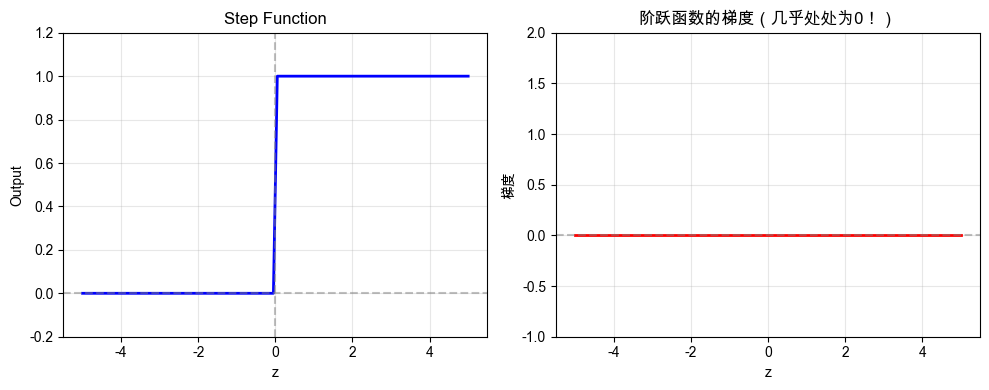


⚠️ 问题：除了 z=0 附近，梯度全是 0！
   这意味着学习信号传不回去！


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 定义阶跃函数
def step(z):
    return (z > 0).float()

# 可视化
z = torch.linspace(-5, 5, 100)
y_step = step(z)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(z.numpy(), y_step.numpy(), 'b-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('Output')
plt.title('Step Function')
plt.ylim(-0.2, 1.2)
plt.grid(True, alpha=0.3)

# 导数（手动计算）
dz = 0.01
grad = []
for zi in z:
    if abs(zi) < 0.5 * dz:  # 在0附近才有非零导数
        grad.append(float('inf'))
    else:
        grad.append(0.0)

plt.subplot(1, 2, 2)
plt.plot(z.numpy(), grad, 'r-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('梯度')
plt.title('阶跃函数的梯度（几乎处处为0！）')
plt.ylim(-1, 2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step_function_problem.png', dpi=150)
plt.show()

print("\n⚠️ 问题：除了 z=0 附近，梯度全是 0！")
print("   这意味着学习信号传不回去！")

---

## 2. Sigmoid：柔和的 S 曲线

Sigmoid 函数：

σ(z) = 1 / (1 + e^(-z))

它的特点：
- 输出在 **(0, 1)** 之间
- 越靠近 0 的输入，输出变化越敏感
- **处处可导**，梯度处处非零

这就像「概率」的表达——0.7 表示「70% 可能是正的」。

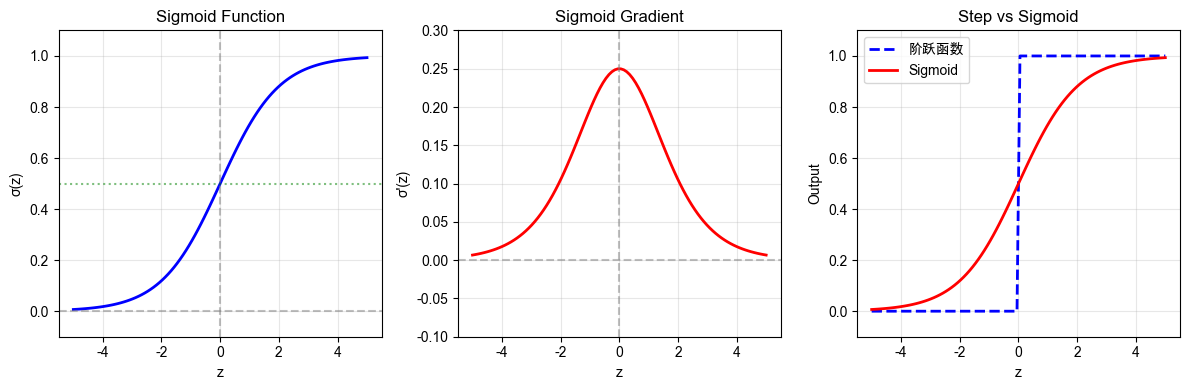


✅ Sigmoid 的Advantages：处处可导，梯度处处非零
   Disadvantages：When z is very large or small, gradient approaches 0 (vanishing gradient)


In [3]:
# Sigmoid Function和它的导数
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

def sigmoid_derivative(z):
    """Sigmoid 导数有一个优美性质：σ'(z) = σ(z) * (1 - σ(z))"""
    s = sigmoid(z)
    return s * (1 - s)

# 可视化
z = torch.linspace(-5, 5, 100)
y_sigmoid = sigmoid(z)
dy_sigmoid = sigmoid_derivative(z)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(z.numpy(), y_sigmoid.numpy(), 'b-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0.5, color='green', linestyle=':', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Function')
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(z.numpy(), dy_sigmoid.numpy(), 'r-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel("σ'(z)")
plt.title('Sigmoid Gradient')
plt.ylim(-0.1, 0.3)
plt.grid(True, alpha=0.3)

# 对比：Sigmoid vs 阶跃
plt.subplot(1, 3, 3)
y_step = (z > 0).float()
plt.plot(z.numpy(), y_step.numpy(), 'b--', linewidth=2, label='阶跃函数')
plt.plot(z.numpy(), y_sigmoid.numpy(), 'r-', linewidth=2, label='Sigmoid')
plt.xlabel('z')
plt.ylabel('Output')
plt.title('Step vs Sigmoid')
plt.legend()
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sigmoid_visualization.png', dpi=150)
plt.show()

print("\n✅ Sigmoid 的Advantages：处处可导，梯度处处非零")
print("   Disadvantages：When z is very large or small, gradient approaches 0 (vanishing gradient)")

---

## 3. ReLU：简单高效的现代激活函数

ReLU（Rectified Linear Unit）：

```
ReLU(z) = max(0, z) = { z  if z > 0
                       { 0  if z ≤ 0
```

特点：
- **计算极简**：只需比较和取最大值
- **稀疏激活**：当 z ≤ 0 时输出 0，部分神经元「失活」
- **梯度高效**：z > 0 时梯度恒为 1，不存在梯度消失

现代深度学习的主流选择！

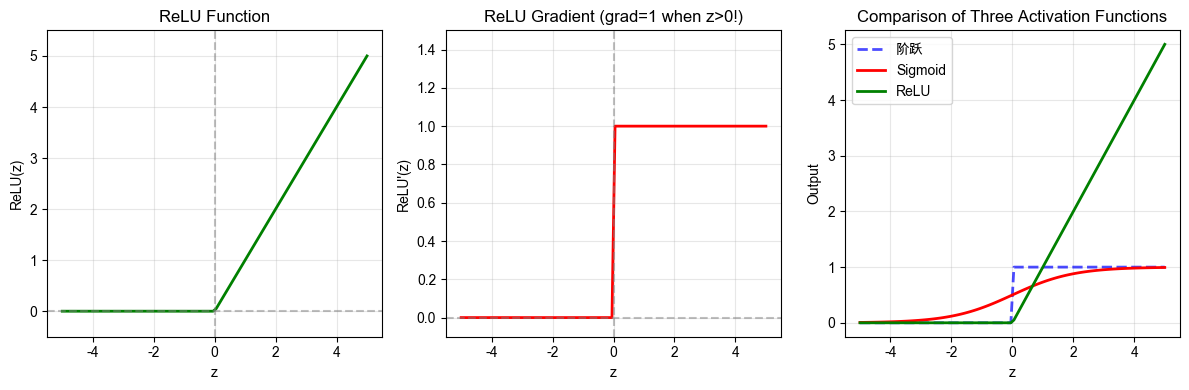


✅ ReLU 的Advantages：Simple computation, efficient gradient (grad=1 when z>0)
   Disadvantages：'Dying' neurons when z<=0, gradient=0


In [4]:
# ReLU Function和它的导数
def relu(z):
    return torch.maximum(z, torch.zeros_like(z))

def relu_derivative(z):
    return (z > 0).float()

# 可视化
z = torch.linspace(-5, 5, 100)
y_relu = relu(z)
dy_relu = relu_derivative(z)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(z.numpy(), y_relu.numpy(), 'g-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('ReLU(z)')
plt.title('ReLU Function')
plt.ylim(-0.5, 5.5)
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(z.numpy(), dy_relu.numpy(), 'r-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel("ReLU'(z)")
plt.title('ReLU Gradient (grad=1 when z>0!)')
plt.ylim(-0.1, 1.5)
plt.grid(True, alpha=0.3)

# 对比三种激活函数
plt.subplot(1, 3, 3)
y_step = (z > 0).float()
y_sigmoid = sigmoid(z)
plt.plot(z.numpy(), y_step.numpy(), 'b--', linewidth=2, label='阶跃', alpha=0.7)
plt.plot(z.numpy(), y_sigmoid.numpy(), 'r-', linewidth=2, label='Sigmoid')
plt.plot(z.numpy(), y_relu.numpy(), 'g-', linewidth=2, label='ReLU')
plt.xlabel('z')
plt.ylabel('Output')
plt.title('Comparison of Three Activation Functions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('activation_functions_comparison.png', dpi=150)
plt.show()

print("\n✅ ReLU 的Advantages：Simple computation, efficient gradient (grad=1 when z>0)")
print("   Disadvantages：'Dying' neurons when z<=0, gradient=0")

---

## 4. 激活函数的数学对比

| 激活函数 | 公式 | 输出范围 | 导数特点 |
|----------|------|----------|----------|
| 阶跃函数 | 1 if z>0 else 0 | {0, 1} | 0（几乎处处） |
| Sigmoid | 1/(1+e^(-z)) | (0, 1) | σ(z)(1-σ(z)) |
| ReLU | max(0, z) | [0, +∞) | 1 if z>0 else 0 |
| Tanh | (e^z-e^(-z))/(e^z+e^(-z)) | (-1, 1) | 1-tanh²(z) |

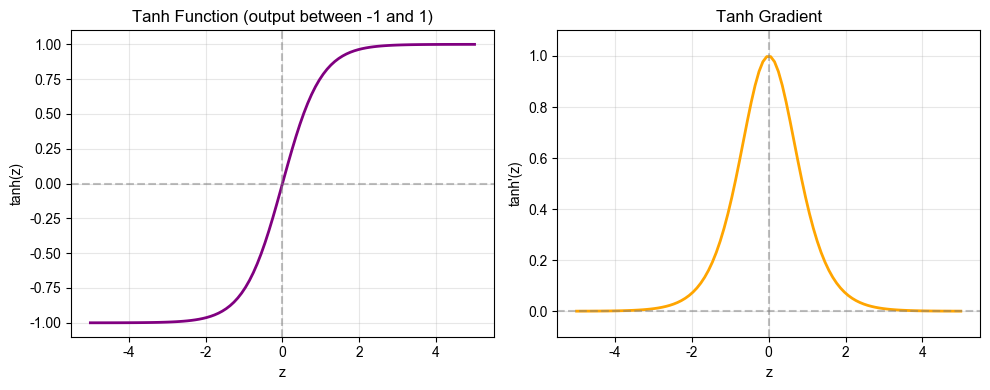


📝 Tanh 是 Sigmoid 的「居中」版本，Output在 (-1, 1)
   Commonly used in RNN and LSTM


In [5]:
# 补充：Tanh 函数（双曲正切）
def tanh(z):
    return torch.tanh(z)

def tanh_derivative(z):
    return 1 - torch.tanh(z)**2

y_tanh = tanh(z)
dy_tanh = tanh_derivative(z)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(z.numpy(), y_tanh.numpy(), 'purple', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('tanh(z)')
plt.title('Tanh Function (output between -1 and 1)')
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(z.numpy(), dy_tanh.numpy(), 'orange', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel("tanh'(z)")
plt.title('Tanh Gradient')
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tanh_visualization.png', dpi=150)
plt.show()

print("\n📝 Tanh 是 Sigmoid 的「居中」版本，Output在 (-1, 1)")
print("   Commonly used in RNN and LSTM")

---

## 5. 在 MLP 中使用激活函数

让我们改造昨天的隐藏层感知机，用 Sigmoid 替代阶跃函数。

In [6]:
class MLPWithSigmoid:
    """
    带 Sigmoid 激活的多层感知机
    """
    def __init__(self):
        # 第一层
        self.W1 = torch.tensor([
            [ 10.0,  10.0],   # 足够大的权重让阶跃变得「陡峭」
            [ 10.0,  10.0]
        ], dtype=torch.float32)
        self.b1 = torch.tensor([[-5.0], [-15.0]], dtype=torch.float32)
        
        # 第二层
        self.W2 = torch.tensor([[10.0], [-10.0]], dtype=torch.float32)
        self.b2 = torch.tensor([[-5.0]], dtype=torch.float32)
        
    def forward(self, X):
        # 第一层：线性变换 + Sigmoid
        z1 = torch.matmul(X, self.W1.T) + self.b1.T
        a1 = sigmoid(z1)  # 使用 Sigmoid
        
        # 第二层：线性变换 + Sigmoid（Output层也用 Sigmoid）
        z2 = torch.matmul(a1, self.W2) + self.b2
        a2 = sigmoid(z2)  # Output在 (0, 1) 之间
        
        return a2

mlp = MLPWithSigmoid()

# XOR Test
X_xor = torch.tensor([
    [0.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
    [1.0, 0.0]
])
y_xor = torch.tensor([1.0, 1.0, 0.0, 0.0])

y_pred = mlp.forward(X_xor)

print("\nSigmoid MLP XOR Results：")
print("="*50)
print(f"{'Input':<12} {'True':<8} {'SigmoidOutput':<15} {'Prediction(>0.5?)'}")
print("-"*50)
for i in range(4):
    x_str = f"({X_xor[i,0].item()}, {X_xor[i,1].item()})"
    true_label = int(y_xor[i].item())
    prob = y_pred[i].item()
    pred = 1 if prob > 0.5 else 0
    status = "✓" if true_label == pred else "✗"
    print(f"{x_str:<12} {true_label:<8} {prob:<15.4f} {pred} {status}")

print("\n📝 Note: Sigmoid outputs probability (0-1), not hard decisions!")
print("   This lets the model express 'uncertainty' - e.g., 0.52 means 'slightly leaning positive'")


Sigmoid MLP XOR Results：
Input        True     SigmoidOutput   Prediction(>0.5?)
--------------------------------------------------
(0.0, 0.0)   1        0.0072          0 ✗
(1.0, 1.0)   1        0.0072          0 ✗
(0.0, 1.0)   0        0.9924          1 ✗
(1.0, 0.0)   0        0.9924          1 ✗

📝 Note: Sigmoid outputs probability (0-1), not hard decisions!
   This lets the model express 'uncertainty' - e.g., 0.52 means 'slightly leaning positive'


---

## 今日总结

| 激活函数 | 输出范围 | 优点 | 缺点 |
|----------|----------|------|------|
| 阶跃 | {0, 1} | 简单 | 梯度为0，无法学习 |
| Sigmoid | (0, 1) | 处处可导，输出是概率 | 梯度消失 |
| ReLU | [0, +∞) | 计算快，梯度不消失 | 神经元死亡 |
| Tanh | (-1, 1) | 居中输出，适合RNN | 梯度消失 |

**关键洞察**：激活函数给神经网络引入了**非线性**。没有它，多层网络等价于单层（矩阵乘法结合律）。

**明天预告**：今天我们手动设定了权重，但模型最终需要**自己学习**。明天学习反向传播（Backpropagation）—— 如何把误差信号传回每一层，从而调整权重。